# The Hidden Climate Cost of Conflict
## Probabilistic Emission Accounting Under Data Uncertainty

**Author:** Anoopkrishna Krishnakumar  
**Case study:** Ukraine conflict emissions (2022–2024)  
**Methodology:** Monte Carlo uncertainty propagation  

---

Armed conflict generates significant GHG and air quality emissions across multiple source categories. Unlike industrial emissions, conflict emissions are inherently uncertain — infrastructure is destroyed, military activity is obscured, and satellite detection has known limitations in active conflict zones.

This makes conflict emissions a textbook Monte Carlo problem: we know approximate magnitudes from published studies, but uncertainty is large, structured, and source-dependent.

**The gap this exposes:** Current GHG accounting frameworks under the Paris Agreement do not adequately handle conflict emissions — the same structural problem that exists for rocket launches and other activities that cross conventional monitoring boundaries.

**Data:** Bun et al. (2024), *Science of the Total Environment*; Initiative on GHG Accounting of War (2025); CEOBS (2024).

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pandas as pd
import os

np.random.seed(42)
N = 100_000

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 120
})

print(f"Monte Carlo conflict emission analysis — {N:,} iterations")

Monte Carlo conflict emission analysis — 100,000 iterations


## 2. Emission Source Inventory

Six source categories (annual MtCO₂e/year) from peer-reviewed literature.

**Design choices:**
- **Annual rates** allow comparison across conflicts of different durations
- **Lognormal distributions** because emissions are strictly positive, uncertainty is multiplicative, and conflict estimates are right-skewed (more likely to underestimate than overestimate)
- **Six categories only** — others exist but lack published uncertainty estimates

| Source | Mean (MtCO₂e/yr) | CV | Basis for uncertainty |
|--------|-----------------|-----|----------------------|
| Military fuel combustion | 27.4 | 0.40 | Fuel consumption classified; vehicle ratios estimated |
| Infrastructure fires | 3.1 | 0.60 | Satellite detection ±60% in smoke-obscured zones |
| Landscape fires | 16.2 | 0.50 | Biomass estimates vary by factor of 13 (CEOBS 2024) |
| Reconstruction embodied carbon | 20.7 | 0.35 | Damage assessment 60–80% complete |
| Aviation rerouting | 4.8 | 0.15 | Flight data publicly tracked; well modelled |
| Black carbon / particulates | 0.5 | 0.80 | Almost no conflict-zone PM measurements exist |

In [2]:
# Annual emission estimates (MtCO2e/year)
# Source: Bun et al. (2024); Initiative on GHG Accounting of War (2025); CEOBS (2024)
emission_sources = {
    'Military_Fuel':       {'mean': 27.4, 'cv': 0.40},
    'Infrastructure_Fire': {'mean': 3.1,  'cv': 0.60},
    'Landscape_Fire':      {'mean': 16.2, 'cv': 0.50},
    'Reconstruction':      {'mean': 20.7, 'cv': 0.35},
    'Aviation_Rerouting':  {'mean': 4.8,  'cv': 0.15},
    'Black_Carbon_PM':     {'mean': 0.5,  'cv': 0.80},
}

def lognormal_params(mean, cv):
    """Convert mean and CV to lognormal mu and sigma."""
    sigma2 = np.log(1 + cv**2)
    mu = np.log(mean) - sigma2 / 2
    return mu, np.sqrt(sigma2)

emission_samples = {}
for source, params in emission_sources.items():
    mu, sigma = lognormal_params(params['mean'], params['cv'])
    emission_samples[source] = np.random.lognormal(mu, sigma, N)

print(f"{'Source':<25} {'Expected':>12} {'Simulated mean':>15}")
print("-" * 54)
for source, samples in emission_samples.items():
    expected = emission_sources[source]['mean']
    print(f"{source:<25} {expected:>12.1f} {samples.mean():>15.1f}")

Source                        Expected  Simulated mean
------------------------------------------------------
Military_Fuel                     27.4            27.4
Infrastructure_Fire                3.1             3.1
Landscape_Fire                    16.2            16.2
Reconstruction                    20.7            20.7
Aviation_Rerouting                 4.8             4.8
Black_Carbon_PM                    0.5             0.5


## 3. Monte Carlo Impact Calculation

Total annual emissions are the sum of all source contributions across N simulations.
Both emission quantities and their uncertainties are propagated simultaneously.
Results are compared against national annual emission benchmarks for context.

In [3]:
total_emissions = np.zeros(N)
source_contributions = {}

for source, samples in emission_samples.items():
    total_emissions += samples
    source_contributions[source] = samples

# National benchmarks for context (annual GHG emissions, MtCO2e)
benchmarks = {
    'Belgium':      114,
    'Netherlands':  170,
    'Austria':       80,
    'Switzerland':   45,
    'Ukraine 2021': 327,
}

print("Annual conflict emission results (MtCO2e/year)")
print("=" * 52)
print(f"Mean:         {total_emissions.mean():>10.1f} MtCO2e/year")
print(f"Median:       {np.median(total_emissions):>10.1f} MtCO2e/year")
print(f"Std dev:      {total_emissions.std():>10.1f} MtCO2e/year")
print(f"P5  – P95:    {np.percentile(total_emissions,5):>10.1f} "
      f"– {np.percentile(total_emissions,95):.1f}")
print(f"P95/P5 ratio: {np.percentile(total_emissions,95)/np.percentile(total_emissions,5):.1f}x")
print(f"\nNational benchmark comparisons:")
for country, value in benchmarks.items():
    ratio = total_emissions.mean() / value
    print(f"  {country:<15}: {value:>6.0f} MtCO2e/yr  ({'%.1f'%ratio}x conflict mean)")

Annual conflict emission results (MtCO2e/year)
Mean:               72.7 MtCO2e/year
Median:             70.9 MtCO2e/year
Std dev:            15.6 MtCO2e/year
P5  – P95:          50.6 – 100.8
P95/P5 ratio: 2.0x

National benchmark comparisons:
  Belgium        :    114 MtCO2e/yr  (0.6x conflict mean)
  Netherlands    :    170 MtCO2e/yr  (0.4x conflict mean)
  Austria        :     80 MtCO2e/yr  (0.9x conflict mean)
  Switzerland    :     45 MtCO2e/yr  (1.6x conflict mean)
  Ukraine 2021   :    327 MtCO2e/yr  (0.2x conflict mean)


## 4. Visualisation

### Figure 1: Total distribution and per-source uncertainty width

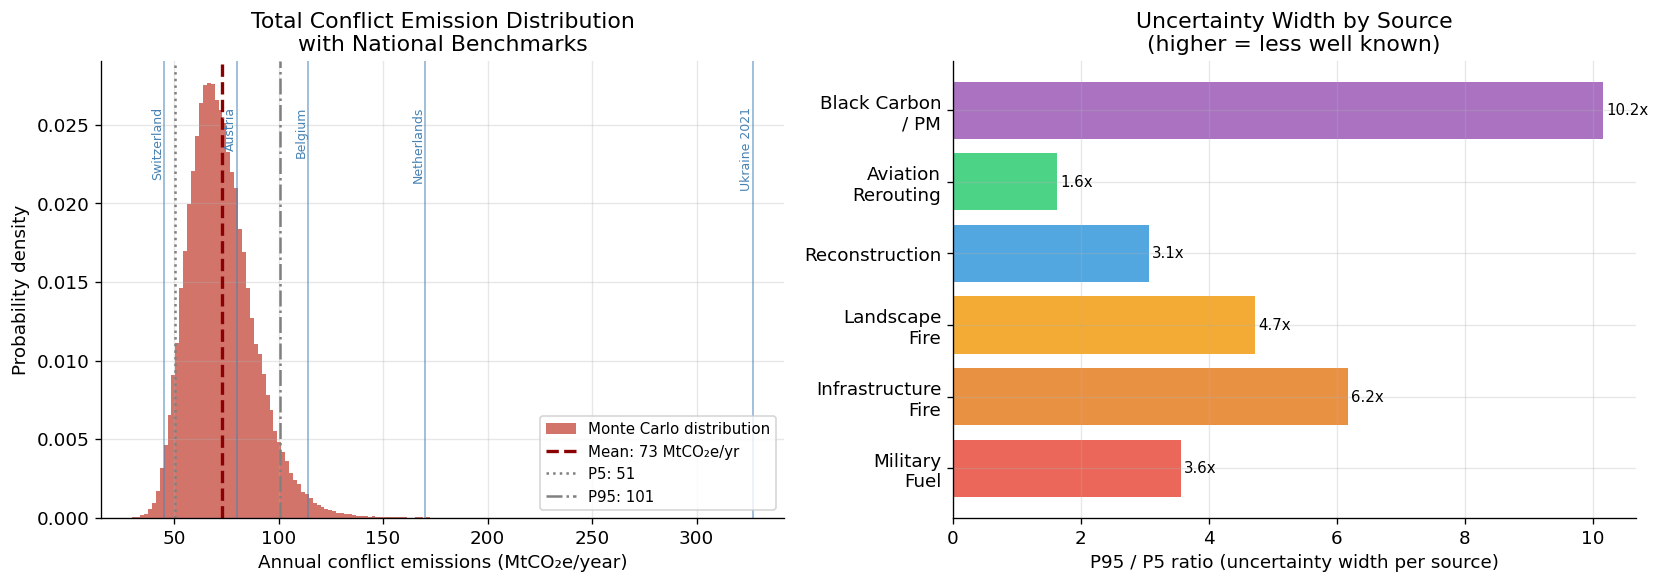

Figure 1 saved.


In [4]:
source_labels = ['Military\nFuel', 'Infrastructure\nFire',
                 'Landscape\nFire', 'Reconstruction',
                 'Aviation\nRerouting', 'Black Carbon\n/ PM']
colors = ['#E74C3C','#E67E22','#F39C12','#3498DB','#2ECC71','#9B59B6']

uncertainty_ratios = [
    np.percentile(source_contributions[s], 95) /
    np.percentile(source_contributions[s], 5)
    for s in emission_sources.keys()
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total distribution with benchmarks
ax = axes[0]
ax.hist(total_emissions, bins=80, color='#C0392B',
        alpha=0.7, density=True, label='Monte Carlo distribution')
ax.axvline(total_emissions.mean(), color='darkred', lw=2, ls='--',
           label=f'Mean: {total_emissions.mean():.0f} MtCO₂e/yr')
ax.axvline(np.percentile(total_emissions, 5), color='grey',
           lw=1.5, ls=':', label=f'P5: {np.percentile(total_emissions,5):.0f}')
ax.axvline(np.percentile(total_emissions, 95), color='grey',
           lw=1.5, ls='-.', label=f'P95: {np.percentile(total_emissions,95):.0f}')
for country, value in benchmarks.items():
    ax.axvline(value, color='steelblue', lw=1, alpha=0.6)
    ax.text(value, ax.get_ylim()[1]*0.9, country,
            rotation=90, fontsize=7.5, color='steelblue', ha='right', va='top')
ax.set_xlabel('Annual conflict emissions (MtCO₂e/year)')
ax.set_ylabel('Probability density')
ax.set_title('Total Conflict Emission Distribution\nwith National Benchmarks')
ax.legend(fontsize=9)

# Right: uncertainty width per source
ax2 = axes[1]
bars = ax2.barh(source_labels, uncertainty_ratios, color=colors, alpha=0.85)
for bar, val in zip(bars, uncertainty_ratios):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}x', va='center', fontsize=9)
ax2.set_xlabel('P95 / P5 ratio (uncertainty width per source)')
ax2.set_title('Uncertainty Width by Source\n(higher = less well known)')

plt.tight_layout()
plt.savefig('figures/01_conflict_distribution_uncertainty.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 1 saved.")

### Figure 2: Source contribution analysis

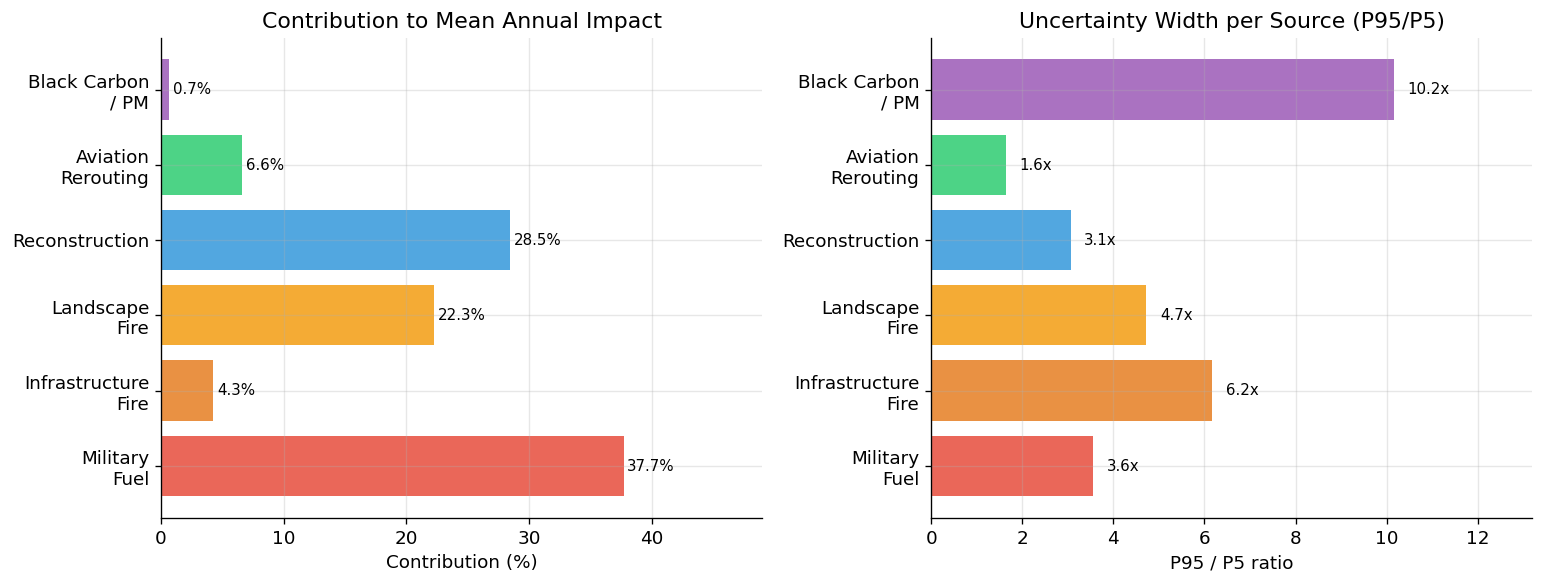

Figure 2 saved.

Key: Military fuel dominates the mean but black carbon/PM
has the widest uncertainty — different sources of concern.


In [5]:
mean_contribs = [source_contributions[s].mean() for s in emission_sources.keys()]
total_mean = sum(mean_contribs)
pct = [c / total_mean * 100 for c in mean_contribs]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, values, title, xlabel, fmt in [
    (axes[0], pct,               'Contribution to Mean Annual Impact', 'Contribution (%)',          '{:.1f}%'),
    (axes[1], uncertainty_ratios,'Uncertainty Width per Source (P95/P5)', 'P95 / P5 ratio',         '{:.1f}x'),
]:
    bars = ax.barh(source_labels, values, color=colors, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                fmt.format(val), va='center', fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.set_xlim(0, max(values) * 1.3)

plt.tight_layout()
plt.savefig('figures/02_conflict_contributions.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 2 saved.")
print("\nKey: Military fuel dominates the mean but black carbon/PM")
print("has the widest uncertainty — different sources of concern.")

### Figure 3: Sensitivity analysis

Pearson correlation identifies which source's uncertainty drives output variance —
where better data would most improve the reliability of total estimates.

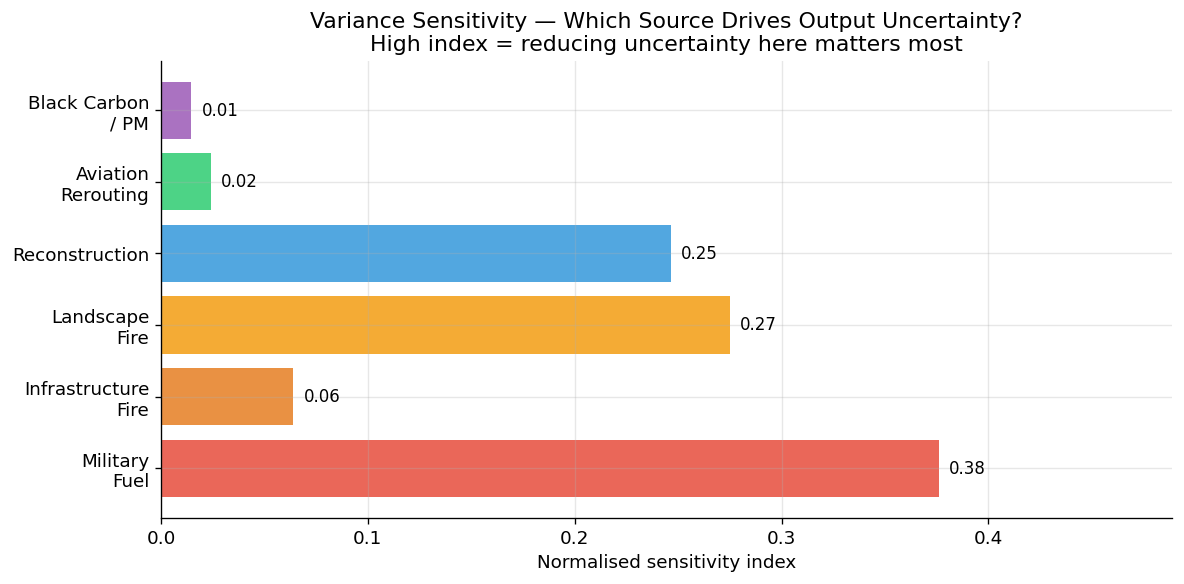

Figure 3 saved.


In [6]:
correlations = [abs(pearsonr(source_contributions[s], total_emissions)[0])
                for s in emission_sources.keys()]
total_corr = sum(correlations)
norm_corr = [c / total_corr for c in correlations]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(source_labels, norm_corr, color=colors, alpha=0.85)
for bar, val in zip(bars, norm_corr):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)
ax.set_xlabel('Normalised sensitivity index')
ax.set_title('Variance Sensitivity — Which Source Drives Output Uncertainty?\n'
             'High index = reducing uncertainty here matters most')
ax.set_xlim(0, max(norm_corr) * 1.3)
plt.tight_layout()
plt.savefig('figures/03_conflict_sensitivity.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 3 saved.")

### Figure 4: Convergence check

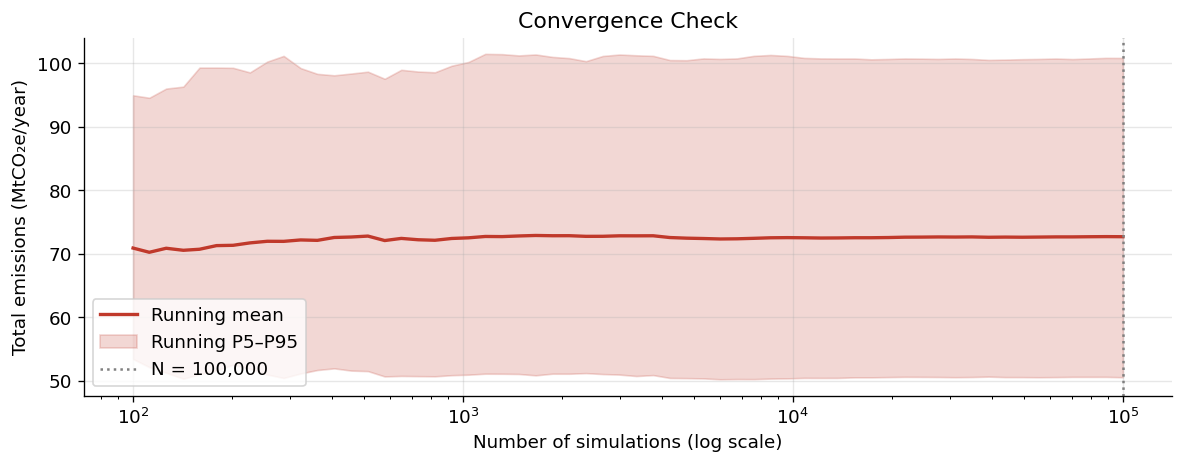

Mean stabilises by ~10,000 simulations.
Percentile bounds stabilise by ~50,000. N=100,000 is sufficient.


In [7]:
checkpoints  = np.logspace(2, 5, 60).astype(int)
running_mean = [total_emissions[:n].mean() for n in checkpoints]
running_p5   = [np.percentile(total_emissions[:n], 5)  for n in checkpoints]
running_p95  = [np.percentile(total_emissions[:n], 95) for n in checkpoints]

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(checkpoints, running_mean, color='#C0392B', lw=2, label='Running mean')
ax.fill_between(checkpoints, running_p5, running_p95,
                alpha=0.2, color='#C0392B', label='Running P5–P95')
ax.axvline(N, color='grey', ls=':', lw=1.5, label=f'N = {N:,}')
ax.set_xlabel('Number of simulations (log scale)')
ax.set_ylabel('Total emissions (MtCO₂e/year)')
ax.set_title('Convergence Check')
ax.legend()
plt.tight_layout()
plt.savefig('figures/04_conflict_convergence.png',
            bbox_inches='tight', dpi=150)
plt.show()
print(f"Mean stabilises by ~10,000 simulations.")
print(f"Percentile bounds stabilise by ~50,000. N={N:,} is sufficient.")

## 5. Summary and Findings

In [8]:
dominant = source_labels[norm_corr.index(max(norm_corr))].replace('\n', ' ')

print("=" * 60)
print("FINDINGS: PROBABILISTIC CONFLICT EMISSION ACCOUNTING")
print("=" * 60)
print(f"""
FINDING 1: SCALE
  Mean annual conflict emissions: {total_emissions.mean():.0f} MtCO2e/year
  Comparable to the annual emissions of Belgium
  ({benchmarks['Belgium']} MtCO2e) to Netherlands ({benchmarks['Netherlands']} MtCO2e).

FINDING 2: UNCERTAINTY IS LARGE
  P5  : {np.percentile(total_emissions,5):.0f} MtCO2e/year
  P95 : {np.percentile(total_emissions,95):.0f} MtCO2e/year
  P95/P5 ratio: {np.percentile(total_emissions,95)/np.percentile(total_emissions,5):.1f}x
  A single-point estimate is not an honest representation.

FINDING 3: DOMINANT VARIANCE DRIVER
  {dominant} has the highest sensitivity index.
  Better measurement here would most improve total estimate reliability.

FINDING 4: THE ACCOUNTING GAP
  Paris Agreement reporting does not require transparent
  conflict emission accounting. The same structural gap
  exists for rocket launches and other activities crossing
  conventional monitoring boundaries.
""")
print("=" * 60)
print("References")
print("=" * 60)
print("""
Bun et al. (2024). Tracking unaccounted GHG emissions due to
  the war in Ukraine. Science of the Total Environment.

Initiative on GHG Accounting of War (2025). Three-year
  assessment: climate damage caused by Russia's war in Ukraine.

CEOBS (2024). Ukraine conflict environmental briefing:
  the climate crisis. Conflict and Environment Observatory.
""")

FINDINGS: PROBABILISTIC CONFLICT EMISSION ACCOUNTING

FINDING 1: SCALE
  Mean annual conflict emissions: 73 MtCO2e/year
  Comparable to the annual emissions of Belgium
  (114 MtCO2e) to Netherlands (170 MtCO2e).

FINDING 2: UNCERTAINTY IS LARGE
  P5  : 51 MtCO2e/year
  P95 : 101 MtCO2e/year
  P95/P5 ratio: 2.0x
  A single-point estimate is not an honest representation.

FINDING 3: DOMINANT VARIANCE DRIVER
  Military Fuel has the highest sensitivity index.
  Better measurement here would most improve total estimate reliability.

FINDING 4: THE ACCOUNTING GAP
  Paris Agreement reporting does not require transparent
  conflict emission accounting. The same structural gap
  exists for rocket launches and other activities crossing
  conventional monitoring boundaries.

References

Bun et al. (2024). Tracking unaccounted GHG emissions due to
  the war in Ukraine. Science of the Total Environment.

Initiative on GHG Accounting of War (2025). Three-year
  assessment: climate damage caused by R